# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten, TimeDistributed, Reshape
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [2]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

No GPU found.


In [3]:
# First removing the path by split and then splitting the string to get the label
# input_path = [i for i in glob('Dataset\*\*\*.mp4')]
input_path = [i for i in glob('MP_Data\*\*.npy')]
output_label = [i.split("\\")[-1] for i in glob('MP_data\*')] 

print(output_label)
# input_path

['Beautiful', 'Blind', 'Deaf', 'happy', 'loud', 'quiet', 'sad', 'Ugly']


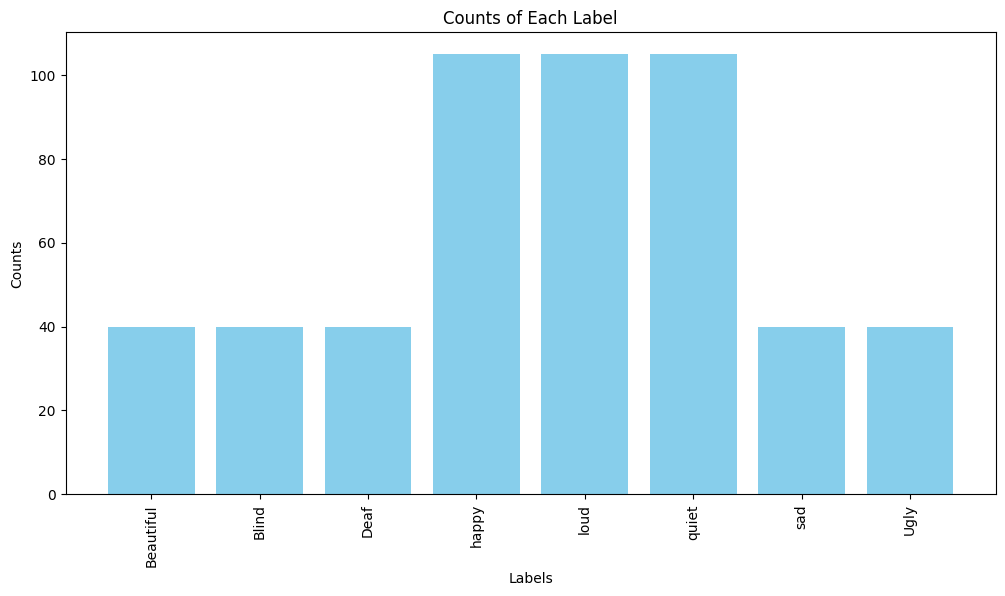

In [4]:
import matplotlib.pyplot as plt

# Count the occurrences of each label in y
label_counts = [len(os.listdir(i)) for i in glob('MP_data\*')]

# Create a bar graph
plt.figure(figsize=(12, 6))
plt.bar(output_label, label_counts, color='skyblue')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Counts of Each Label')
plt.xticks(rotation=90)
plt.show()

In [5]:
labels = pd.Series(output_label).unique()
labels = pd.Series(labels).to_list()

train_path = pd.Series(input_path)

train_path.sample(5),len(labels)
train_path[460]

'MP_Data\\sad\\MVI_9720.npy'

In [6]:
label_map = dict()

for i in range(len(labels)):
    for j in input_path:
        sep = j.split("\\")
        cur_label  = sep[-2].split(" ")[-1]
    label_map[i] = labels[i]
            
label_map    

{0: 'Beautiful',
 1: 'Blind',
 2: 'Deaf',
 3: 'happy',
 4: 'loud',
 5: 'quiet',
 6: 'sad',
 7: 'Ugly'}

In [7]:
# Loading all the labeled videos in the dataset
X = []
y = []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label) 
    
    
    for video in label_videos:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
        
        # Prinintg npy file containing face mesh
        if len(res[0]) == 1662:
            print(video)
        
        X.append(res)
        y.append(labels.index(label))      

len(X),len(y)

  0%|          | 0/8 [00:00<?, ?it/s]

(515, 515)

In [8]:
for i in range(len(X)):
    if len(X[i][0]) == 1662:
        print(i,y[i])

In [9]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))

# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
print(f"Max frames: {max_frames}")

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape)

Max frames: 79
(515, 79, 258)


In [10]:
X= np.array(X)
y= np.array(y)
# X= tf.convert_to_tensor(X)
# y= tf.convert_to_tensor(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (412, 79, 258)
X_val shape: (103, 79, 258)
y_train shape: (412, 8)
y_val shape: (103, 8)


# Model

## Architecture

In [11]:
import keras

# input_shape = (79, 1662)
input_shape = X_train[0].shape #(79, 1662)
num_classes =  len(label_map.keys())#50
input_shape,num_classes

((79, 258), 8)

In [10]:


INCLUDE8_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,476,168 (9.45 MB)

 Trainable params: 2,476,168 (9.45 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 79, 128)        │       165,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 79, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 79, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,888,392 (7.20 MB)

 Trainable params: 1,888,392 (7.20 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.layers import Dropout

INCLUDE8_V4 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Dropout(0.1),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.1),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        Dropout(0.5),
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V4

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_4 (Dropout)             │ (None, 79, 258)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 79, 128)        │       165,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 79, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 79, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 79, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 79, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 79, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       647,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,242,472 (4.74 MB)

 Trainable params: 1,242,472 (4.74 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=35)
        #   ,callbacks=[early_stop])

Epoch 1/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - accuracy: 0.1942 - loss: 2.0736 - val_accuracy: 0.2913 - val_loss: 1.8295
Epoch 2/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.3536 - loss: 1.6456 - val_accuracy: 0.3981 - val_loss: 1.5066
Epoch 3/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 0.4763 - loss: 1.2766 - val_accuracy: 0.3398 - val_loss: 1.5683
Epoch 4/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accuracy: 0.4230 - loss: 1.3275 - val_accuracy: 0.5340 - val_loss: 1.0634
Epoch 5/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 476ms/step - accuracy: 0.5011 - loss: 1.1249 - val_accuracy: 0.4369 - val_loss: 1.1933
Epoch 6/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 374ms/step - accuracy: 0.5345 - loss: 1.0276 - val_accuracy: 0.5825 - val_loss: 0.9719
Epoch 7/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.6405 - loss: 0.8348 - val_accuracy: 0.6408 - val_loss: 0.8207
Epoch 8/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.6620 - loss: 0.8069 - val_accuracy: 0

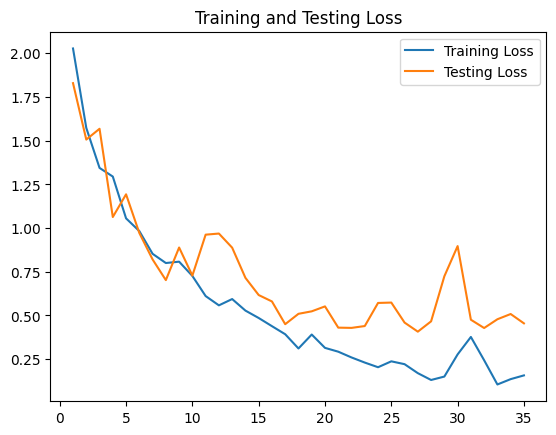

<Figure size 640x480 with 0 Axes>

In [16]:
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

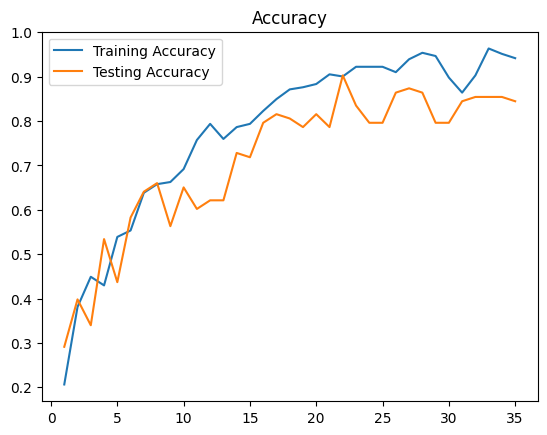

<Figure size 640x480 with 0 Axes>

In [17]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

In [18]:
# Predict probabilities for the test data
probabilities = model.predict(X_val)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)

total = len(X_val)
pred = 0
for i in range(total):
   if (label_map[predicted_classes[i]]) == (label_map[np.argmax(y_val[i])]):
         pred += 1

acc = (pred/total)*100

acc, total,pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 562ms/step


(84.46601941747572, 103, 87)

In [19]:
# model.save('INCLUDE_8_V1.h5')
try:
    os.mkdir("Model")
except:
    pass

model.save("Model\INCLUDE_8_V_noFace_dropout.h5")